# **MVP Análise de Dados e Boas Práticas**

Nome: Gabriel Amaral Souza

Matrícula: 4052025000129

Dataset: Campeonato Brasileiro de Futebol

O dataset original pode ser encontrado no repositório do Github no link a seguir: https://raw.githubusercontent.com/adaoduque/Brasileirao_Dataset/refs/heads/master/campeonato-brasileiro-estatisticas-full.csv

**Objetivo Geral**

Analisando as partidas do campeonato, utilizar algoritmos de machine learning para indicar quais clubes possuem perfis de jogo mais e menos ofensivos.

**ANÁLISE EXPLORATÓRIA DOS DADOS**

Os atributos são as características escolhidas no dataset para provar a hipótese de resolução do problema.

**Atributos:**
- Quantidade de passes
- Posse de bola
- Finalizações
- Faltas

In [68]:
""" Vamos começar importando as bibliotecas que usaremos (Pandas para análise exploratória e tratamento,
seaborn e matplotlib no auxílio da visualização dos dados e uma função para o pré-processamento), além de algumas bibliotecas para o treinamento
de Machine Learning """

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder # Pré-Processamento
from sklearn.model_selection import train_test_split, cross_val_score, KFold # Validação cruzada
from sklearn.neighbors import KNeighborsClassifier # Algoritmo KNN
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # Verificar acurácia do algoritmo
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from scipy.stats import loguniform
import warnings

# Ignorar tipos específicos de warning
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

plt.style.use('seaborn-v0_8')
np.random.seed(42)

# Iremos carregar o dataset através do link Github citado no início do documento.
# Definimos uma variável para receber o link
url = 'https://raw.githubusercontent.com/gabriel-amaral1/mvp-machine-learning/refs/heads/main/campeonato-brasileiro-estatisticas-full.csv'

# Carregamos o dataset
df = pd.read_csv(url)

# **ANÁLISE EXPLORATÓRIA DOS DADOS**

Para a resolução do problema, através de uma análise descritiva, será possível justificar a correlação entre os atributos escolhidos em cada análise.

In [69]:
# Analisando o tamanho do dataset
df.shape

(17570, 13)

O dataset possui **17.570 instâncias e 13 colunas**.

In [70]:
# Analisando inicialmente as primeiras linhas do dataset
df.head()

,partida_id,rodata,clube,chutes,chutes_no_alvo,posse_de_bola,passes,precisao_passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios
0,1,1,Vasco,0,0,NaN,0,NaN,0,0,0,0,0
1,1,1,Guarani,0,0,NaN,0,NaN,0,0,0,0,0
2,2,1,Athletico-PR,0,0,NaN,0,NaN,0,0,0,0,0
3,2,1,Gremio,0,0,NaN,0,NaN,0,0,0,0,0
4,3,1,Flamengo,0,0,NaN,0,NaN,0,0,0,0,0


In [71]:
# Mostrando as últimas linhas do dataset
df.tail()

,partida_id,rodata,clube,chutes,chutes_no_alvo,posse_de_bola,passes,precisao_passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios
17565,8776,38,Fortaleza,0,0,NaN,0,NaN,0,0,0,0,0
17566,8780,38,Criciuma,0,0,NaN,0,NaN,0,0,0,0,0
17567,8780,38,Bragantino,0,0,NaN,0,NaN,0,0,0,0,0
17568,8785,38,Gremio,0,0,NaN,0,NaN,0,0,0,0,0
17569,8785,38,Corinthians,0,0,NaN,0,NaN,0,0,0,0,0


Ao analisar as primeiras e últimas linhas, pode-se perceber colunas com valores vazios, sendo algumas delas os atributos escolhidos.



In [72]:
# Os tipos de dados presentes no dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17570 entries, 0 to 17569
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   partida_id       17570 non-null  int64 
 1   rodata           17570 non-null  int64 
 2   clube            17570 non-null  object
 3   chutes           17570 non-null  int64 
 4   chutes_no_alvo   17570 non-null  int64 
 5   posse_de_bola    6820 non-null   object
 6   passes           17570 non-null  int64 
 7   precisao_passes  4512 non-null   object
 8   faltas           17570 non-null  int64 
 9   cartao_amarelo   17570 non-null  int64 
 10  cartao_vermelho  17570 non-null  int64 
 11  impedimentos     17570 non-null  int64 
 12  escanteios       17570 non-null  int64 
dtypes: int64(10), object(3)
memory usage: 1.7+ MB


Nota-se que a maioria dos dados são numéricos e o restante são do tipo object, ou seja, ocorre uma mistura entre número e texto.

In [73]:
# Alguns dados descritivos do dataset, como a média, desvio padrão, o valor mínimo e máximo de cada tabela, entre outros.
df.describe()

,partida_id,rodata,chutes,chutes_no_alvo,passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios
count,17570.000000,17570.000000,17570.000000,17570.000000,17570.000000,17570.000000,17570.000000,17570.000000,17570.000000,17570.000000
mean,4393.000000,20.105862,5.007057,1.300512,163.839841,5.806659,0.899715,0.049687,0.635743,2.034548
std,2536.083213,11.424747,7.020169,2.351677,214.907730,7.803707,1.443794,0.237575,1.230060,3.158874
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2197.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4393.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6589.000000,30.000000,11.000000,2.000000,379.000000,13.000000,2.000000,0.000000,1.000000,4.000000
max,8785.000000,46.000000,37.000000,18.000000,848.000000,34.000000,10.000000,3.000000,10.000000,23.000000


Analisando o descritivo dos valores das colunas, consegue-se notar que apenas no último quartil os valores estatísticos da maioria das colunas começam a aparecer, além do valor máximo em algumas colunas como "cartao_amarelo" e "passes", por exemplo, sugerindo que há outliers no dataset.

In [74]:
# Verificando quantidade de nulos
df.isnull().sum()

,0
partida_id,0
rodata,0
clube,0
chutes,0
chutes_no_alvo,0
posse_de_bola,10750
passes,0
precisao_passes,13058
faltas,0
cartao_amarelo,0


O histograma ajuda a analisar a distribuição dos dados.

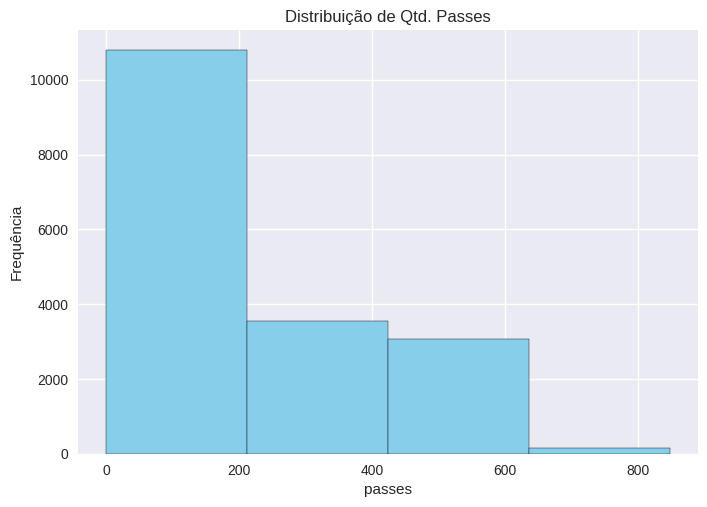

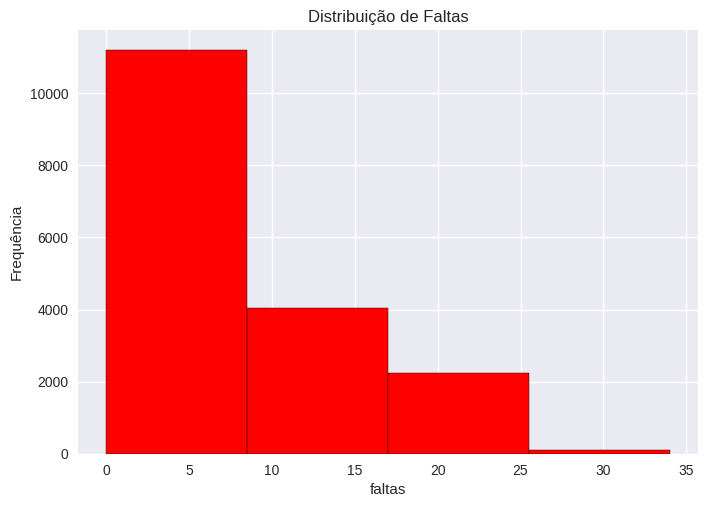

In [75]:
# Podemos analisar o histograma de alguns atributos
# Quantidade de Passes
plt.hist(df['passes'], bins=4, color='skyblue', edgecolor='black')
plt.title('Distribuição de Qtd. Passes')
plt.xlabel('passes')
plt.ylabel('Frequência')
plt.show()

# Faltas
plt.hist(df['faltas'], bins=4, color='red', edgecolor='black')
plt.title('Distribuição de Faltas')
plt.xlabel('faltas')
plt.ylabel('Frequência')
plt.show()

Nota-se que a distribuição do dataset original, se concentra bastante nos valores vazios, como identificado nas análises anteriores, além da presença, com pouca frequência, de possíveis outliers.

Além do destaque que se dá à semelhança extrema das frequências nos mesmos intervalos.

# **VISUALIZAÇÃO DE DADOS E PRÉ PROCESSAMENTO**

A visualização de dados é utilizada tanto para exibição da distribuição dos dados como auxílio para tratamento dos dados. A visualização e o pré-processamento podem ser usadas numa mesma tarefa. No pré-processamento, a limpeza começa dos dados eliminando os valores vazios, colunas desnecessárias e analisando possíveis outliers. Mas antes o dataset original será armazenado numa variável antes de começar o tratamento.

In [76]:
# Salvando o dataset original
dfOriginal = df

# Eliminando os valores vazios
dfNovo = df.dropna()

# Eliminando colunas desnecessárias. O motivo da retirada é que eles são irrelevantes para a análise com base na hipótese.
dfNovo = dfNovo.drop('cartao_amarelo', axis = 1)
dfNovo = dfNovo.drop('impedimentos', axis = 1)
dfNovo = dfNovo.drop('chutes_no_alvo', axis = 1)
dfNovo = dfNovo.drop('precisao_passes', axis = 1)
dfNovo = dfNovo.drop('escanteios', axis = 1)
dfNovo = dfNovo.drop('cartao_vermelho', axis = 1)

# Transformando a coluna de posse de bola em numérico para poder obter dados descritivos do atributo.
dfNovo['posse_de_bola'] = dfNovo['posse_de_bola'].str.extract('(\d+)').astype(int)

# Exibindo com a retirada dos registros com os valores vazios
dfNovo

<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-3330345552.py:16: SyntaxWarning: invalid escape sequence '\d'
  dfNovo['posse_de_bola'] = dfNovo['posse_de_bola'].str.extract('(\d+)').astype(int)


,partida_id,rodata,clube,chutes,posse_de_bola,passes,faltas
12250,6126,1,Gremio,6,60,649,15
12251,6126,1,Cruzeiro,12,40,425,20
12252,6127,1,Vitoria,21,66,545,24
12253,6127,1,Flamengo,10,34,286,10
12254,6128,1,Ceara,10,46,472,5
...,...,...,...,...,...,...,...
16805,8403,38,Fortaleza,14,45,295,9
16806,8404,38,Flamengo,10,58,535,16
16807,8404,38,Sao Paulo,9,42,406,13
16808,8405,38,Bragantino,9,55,398,14


In [77]:
# Verificando se ainda existem dados nulos
dfNovo.isnull().sum()

,0
partida_id,0
rodata,0
clube,0
chutes,0
posse_de_bola,0
passes,0
faltas,0


Conclui-se que o dataset está praticamente normalizado, apenas com dados relevantes, melhorando a eficiência da análise.

In [78]:
# Tamanho do dataset tratado (4512 instâncias e 7 colunas)
dfNovo.shape

(4512, 7)

In [79]:
# Descritivo do novo dataset
dfNovo.describe()

,partida_id,rodata,chutes,posse_de_bola,passes,faltas
count,4512.000000,4512.000000,4512.000000,4512.000000,4512.000000,4512.000000
mean,7271.160904,19.476950,13.103059,50.000000,424.615248,14.770833
std,659.332831,10.974443,5.131459,11.012317,102.684251,4.335340
min,6126.000000,1.000000,1.000000,20.000000,170.000000,2.000000
25%,6698.750000,10.000000,9.000000,42.000000,350.000000,12.000000
50%,7277.500000,19.000000,13.000000,50.000000,419.000000,15.000000
75%,7841.250000,29.000000,16.000000,58.000000,493.000000,18.000000
max,8405.000000,38.000000,37.000000,80.000000,848.000000,31.000000


Com isso, podemos notar que houve uma mudança significativa na distribuição dos dados, fazendo com que os dados façam um pouco mais de sentido e o desvio padrão varie corretamente de acordo com a média.

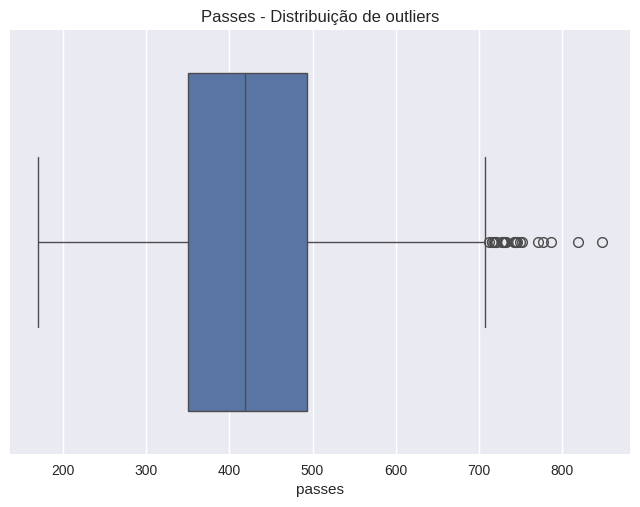

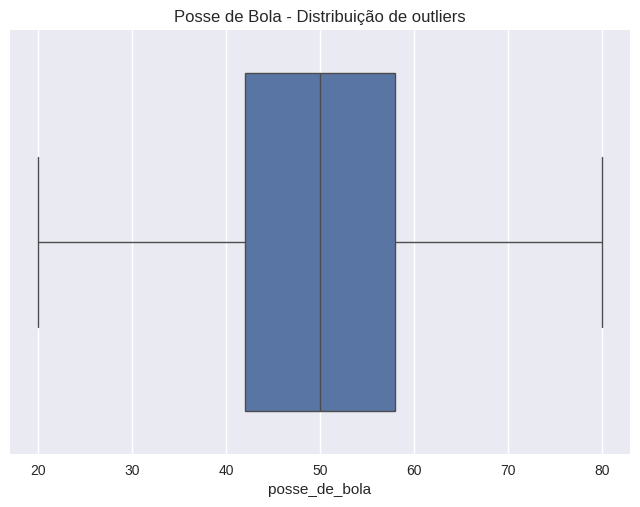

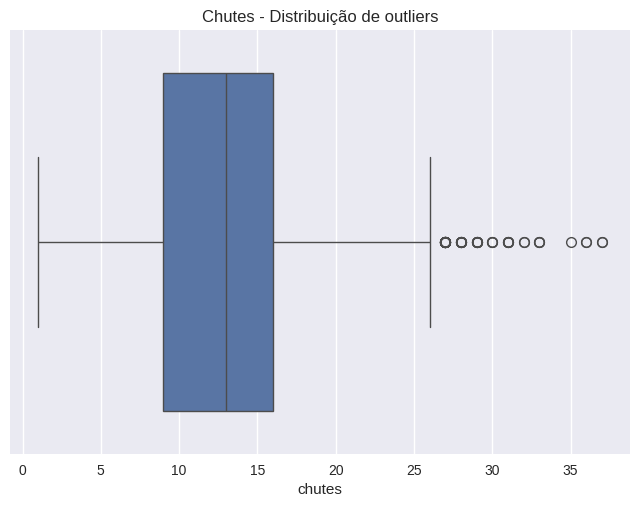

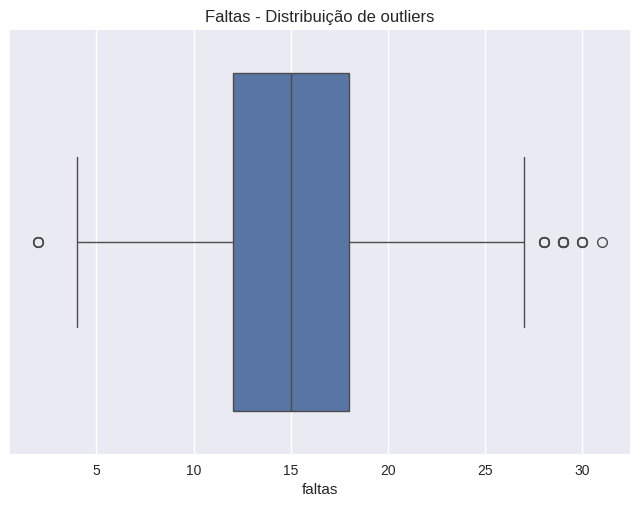

In [80]:
# Analisando, visualmente, a distribuição de outliers em relação à quantidade de passes.
sns.boxplot(data=dfNovo, x='passes')
plt.title("Passes - Distribuição de outliers")
plt.show()

# Mostrando os outliers dos atributos restantes
# Posse de bola
sns.boxplot(data=dfNovo, x='posse_de_bola')
plt.title("Posse de Bola - Distribuição de outliers")
plt.show()

# Chutes

sns.boxplot(data=dfNovo, x='chutes')
plt.title("Chutes - Distribuição de outliers")
plt.show()

# Faltas

sns.boxplot(data=dfNovo, x='faltas')
plt.title("Faltas - Distribuição de outliers")
plt.show()

Apenas a posse de bola não possui outliers. Em relação às faltas, no tratamento, o parâmetro de faltas será alterado, por acreditar que em uma partida de futebol, o time possa cometer pouquíssimas faltas, diferente da quantidade alta, que pelo mesmo contexto, há um lógica melhor em tratar os outliers superiores.

A remoção dos outliers será feito utilizado o IQR. Eliminando distorções por completo.

O IQR consiste em calcular o primeiro e o último quartil estabelecendo limites em cada um deles. Após isso, os valores que se encontrarem abaixo ou acima do limite são desconsiderados.

Cabe à análise entender se faz sentido manter os limites ou não.

In [81]:
# Calcular IQR
# Removendo outliers dos passes
Q1_p = dfNovo['passes'].quantile(0.25)
Q3_p = dfNovo['passes'].quantile(0.75)
IQR_p = Q3_p - Q1_p

# Limites inferior e superior
limite_inferior = Q1_p - 1.5 * IQR_p
limite_superior = Q3_p + 1.5 * IQR_p

df_sem_outliers_passe = dfNovo[
    (dfNovo['passes'] >= limite_inferior) &
    (dfNovo['passes'] <= limite_superior)
]

print(f"Limite inferior dos passes: {limite_inferior}")
print(f"Limite superior dos passes: {limite_superior}")

print("")

# Removendo outliers das finalizações
Q1_fin = df_sem_outliers_passe['chutes'].quantile(0.25)
Q3_fin = df_sem_outliers_passe['chutes'].quantile(0.75)
IQR_fin = Q3_fin - Q1_fin

# Limites inferior e superior
limite_inferior_fn = Q1_fin - 1.5 * IQR_fin
limite_superior_fn = Q3_fin + 1.5 * IQR_fin

df_sem_outliers_2 = df_sem_outliers_passe[
    (df_sem_outliers_passe['chutes'] >= limite_inferior_fn) &
    (df_sem_outliers_passe['chutes'] <= limite_superior_fn)
]

print(f"Limite inferior das finalizações: {limite_inferior_fn}")
print(f"Limite superior das finalizações: {limite_superior_fn}")

print("")

# Removendo outliers das faltas
Q1_faltas = dfNovo['faltas'].quantile(0.25)
Q3_faltas = dfNovo['faltas'].quantile(0.75)
IQR_faltas = Q3_faltas - Q1_faltas

# Limite superior
limite_superior_f = Q3_faltas + 1.5 * IQR_faltas

df_sem_outliers_3 = df_sem_outliers_2[
    (df_sem_outliers_2['faltas'] <= limite_superior_f)
]

print(f"Limite superior das faltas: {limite_superior_f}")

Limite inferior dos passes: 135.5
Limite superior dos passes: 707.5

Limite inferior das finalizações: -1.5
Limite superior das finalizações: 26.5

Limite superior das faltas: 27.0


Ao analisar os limites calculados, conclui-se que apenas o limite superior, em relação ao limite de faltas, será levado em conta. Para um jogo, um número mínimo de faltas faz mais sentido que um número exagerado de faltas, pois dentro do contexto, um time não faria uma grande quantidade de faltas por consequência de ter vários de seus jogadores expulsos.

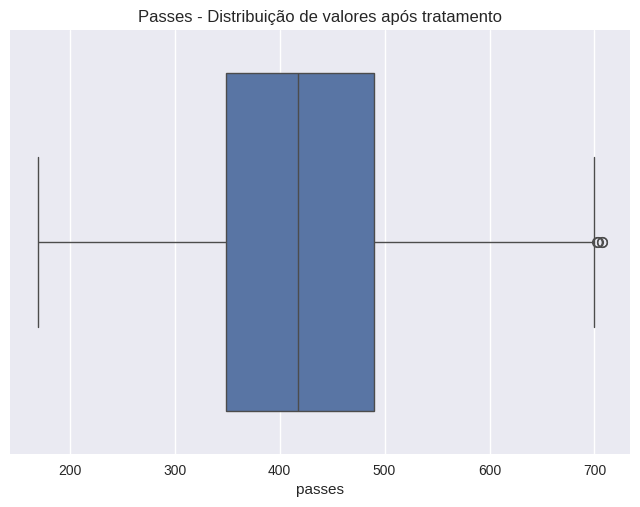

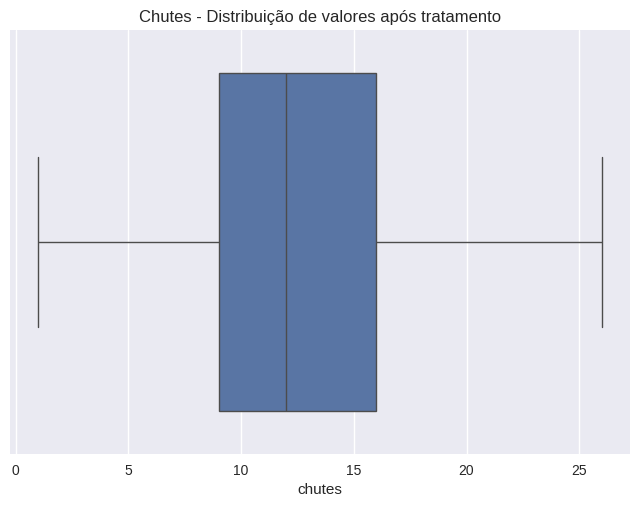

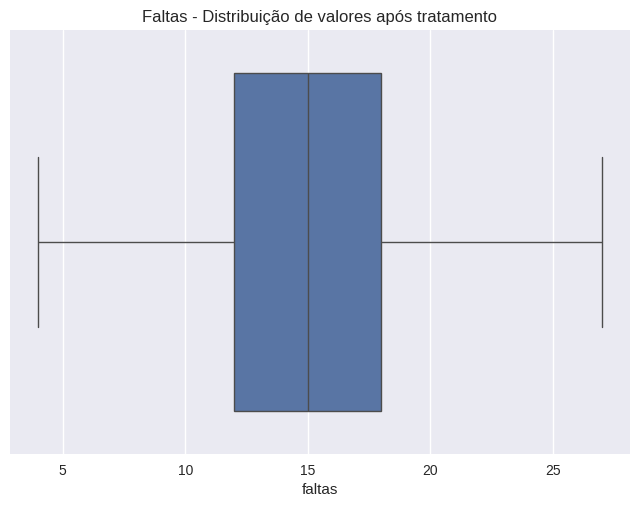

In [82]:
# Verificando a distribuição dos valores
# Passes
sns.boxplot(data=df_sem_outliers_3, x='passes')
plt.title("Passes - Distribuição de valores após tratamento")
plt.show()

# Verificando a distribuição dos valores
# Finalizações
sns.boxplot(data=df_sem_outliers_3, x='chutes')
plt.title("Chutes - Distribuição de valores após tratamento")
plt.show()

# Faltas
sns.boxplot(data=df_sem_outliers_3, x='faltas')
plt.title("Faltas - Distribuição de valores após tratamento")
plt.show()


Com a eliminação dos outliers, é possível seguir para a próxima etapa do pré-processamento, escolhendo um algoritmo que se encaixe no contexto analisado.

Neste problema de **aprendizado não supervisionado**, onde o algoritmo não tem uma saída para analisar os dados, utiliza-se o algoritmo de **normalização**. Através dela, permite dar aos atributos pesos iguais, independente da quantidade ou do tipo de dado de cada um, já que, dependendo do atributo, os valores podem variar bastante, como quantidade de passes e finalizações, por exemplo.

In [83]:
# Aplicando normalização nos atributos

# A função normaliza os dados dos atributos entre 0 e 1
scaler = MinMaxScaler()
valores_normalizados = scaler.fit_transform(
    df_sem_outliers_3[['passes', 'posse_de_bola', 'chutes', 'faltas']]
)

# A função faz os valores normalizados entrarem nas últimas colunas do dataset
df_sem_outliers_3.loc[:, ['passes_norm', 'posse_norm', 'finalizacoes_norm', 'faltas_norm']] = valores_normalizados

# Atribundo a variável do dataframe final
df_final = df_sem_outliers_3

# Mostrando a versão final do dataset
df_final.describe()

,partida_id,rodata,chutes,posse_de_bola,passes,faltas,passes_norm,posse_norm,finalizacoes_norm,faltas_norm
count,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000
mean,7270.358162,19.490831,12.897894,49.743265,422.006113,14.762282,0.469285,0.504123,0.475916,0.467925
std,659.082830,10.971635,4.834136,10.841129,99.701526,4.235386,0.185664,0.183748,0.193365,0.184147
min,6126.000000,1.000000,1.000000,20.000000,170.000000,4.000000,0.000000,0.000000,0.000000,0.000000
25%,6698.000000,10.000000,9.000000,42.000000,349.000000,12.000000,0.333333,0.372881,0.320000,0.347826
50%,7277.000000,20.000000,12.000000,49.000000,418.000000,15.000000,0.461825,0.491525,0.440000,0.478261
75%,7840.000000,29.000000,16.000000,58.000000,490.000000,18.000000,0.595903,0.644068,0.600000,0.608696
max,8405.000000,38.000000,26.000000,79.000000,707.000000,27.000000,1.000000,1.000000,1.000000,1.000000


Observa-se que independente do tipo do valor, seja ele um número pequeno ou não, os valores normalizados estabelecem escalas bem definidas e atribuindo o mesmo peso para todos, dando mais equilíbrio ao analisar as hipóteses levantadasm, finalizando a etapa de pré-processamento, dando início a etapa de Machine Learning.

# **MACHINE LEARNING**

O Machine Learning é uma técnica de Inteligência Artificial utilizada para um algoritmo aprender com os dados fornecidos e com a análise que se quer obter.

Os algoritmos mais indicados são:

KNN. Este algoritmo de **classificação** consiste em classificar os times em pequenos grupos, buscando através dos atributos normalizados, os que possuem maior similaridade de resultados. Para a validação, utilizar este algoritmo se enquadra melhor que outras opções como o algoritmo de Naive Bayes e SVM, ambos também de classificação.

Naive Bayes, para o problema proposto, não se encaixa pois como os atributos são extremamente correlacionadas, pode perder desempenho e acurácia.

SVM (Support Vector Machine) é bom quando há uma separação (mesmo parcial) entre classes.

Para iniciarmos a codificação do algoritmo, devemos entender quais os objetivos propostos para que através do atributos, o algoritmo entenda como deve aprender e qual objetivo atingir.


Primeiramente, devemos dividir o dataset em duas bases: de treino e teste. 70% da base será de treino e 30% de teste. Isso é feito para que possamos treinar o algoritmo utilizando uma pequena parte da base para que o algoritmo aprenda como se comportar e dando margem para possíveis ajustes, caso necessários.



In [84]:
atributos = ["passes_norm", "posse_norm", "finalizacoes_norm", "faltas_norm"]
limiar = df_final["finalizacoes_norm"].median()
df_final["ofensivo"] = (df_final["finalizacoes_norm"] > limiar).astype(int)
X = df_final[atributos]
y = df_final["ofensivo"]

# Normalização (necessária para KNN e SVM)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Divisão treino/teste (70/30 com estratificação para balancear classes)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)


Não foi observado underfitting — os modelos conseguiram aprender padrões nos dados.

Foram escolhidos três algoritmos para treinamento:

KNN, que trabalha com o conceito de vizinhança, ou seja, os mais similares ficam mais juntos, dividindo-se em grupos de acordo com os atributos selecionados.

O Naive Bayes utiliza probabilidade em sua análise, ou seja, as chances da hipótese analisada acontecer.

SVM trabalha com classes claramente definidas, o que também ajuda a entender melhor as classificações que o algortimo possui.

In [85]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(kernel="linear", C=1, probability=True)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Modelo: {name}")
    print("Acurácia:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("-"*50)


Modelo: KNN
Acurácia: 0.9841628959276018
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       664
           1       0.98      0.98      0.98       662

    accuracy                           0.98      1326
   macro avg       0.98      0.98      0.98      1326
weighted avg       0.98      0.98      0.98      1326

--------------------------------------------------
Modelo: Naive Bayes
Acurácia: 0.9268476621417798
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       664
           1       0.94      0.92      0.93       662

    accuracy                           0.93      1326
   macro avg       0.93      0.93      0.93      1326
weighted avg       0.93      0.93      0.93      1326

--------------------------------------------------
Modelo: SVM
Acurácia: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       664
           1       

A acurácia de cada um é bastante alta, dando destaque para o SVM com 100%.

Para extrair o máximo potencial de cada algoritmo, foi implementado um processo sistemático de otimização utilizando a técnica de busca em grade (GridSearchCV). Esta abordagem metódica permitiu explorar de forma exaustiva as combinações mais promissoras de configurações para cada modelo.

No caso do KNN, a otimização focou em três parâmetros fundamentais: o número de vizinhos (n_neighbors), que determina a abrangência da consulta por similaridade; a função de pesos (weights), que define se todos os vizinhos contribuem igualmente ou se os mais próximos têm maior influência; e a métrica de distância (metric), que estabelece como a similaridade entre as instâncias é calculada.

Para o SVM, a busca abrangeu parâmetros cruciais para o desempenho do algoritmo: o parâmetro de regularização (C), que controla o trade-off entre achieving um classificador com margem máxima e minimizar os erros de treinamento; o tipo de kernel, que determina a função utilizada para mapear os dados para um espaço de características de maior dimensionalidade; e o parâmetro gamma, que define a influência de cada exemplo de treinamento, sendo particularmente importante para kernels não lineares.

A estratégia de validação cruzada com 5 folds garantiu que a avaliação de cada combinação de parâmetros fosse estatisticamente robusta, prevenindo que configurações superotimizadas para um conjunto específico de dados fossem selecionadas. Ao calcular a acurácia média através de cinco partições diferentes dos dados, o processo identificou as configurações que demonstraram melhor capacidade de generalização, assegurando que o desempenho observado refletisse consistentemente a verdadeira capacidade preditiva dos modelos.

In [86]:
# KNN
param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring="accuracy")
grid_knn.fit(X_train, y_train)

print("Melhor KNN:", grid_knn.best_params_, "Acurácia média CV:", grid_knn.best_score_)

# SVM
param_grid_svm = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(SVC(probability=True), param_grid_svm, cv=5, scoring="accuracy")
grid_svm.fit(X_train, y_train)

print("Melhor SVM:", grid_svm.best_params_, "Acurácia média CV:", grid_svm.best_score_)


Melhor KNN: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'} Acurácia média CV: 0.9938521783229032
Melhor SVM: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'} Acurácia média CV: 1.0


A avaliação dos modelos individuais revelou perfis de desempenho distintos. Cada algoritmo — KNN, SVM e Naive Bayes — apresentou características próprias, com pontos fortes e limitações específicas, refletindo suas diferentes fundamentações teóricas e abordagens de aprendizado.

Um aspecto particularmente positivo dos resultados foi a ausência de overfitting significativo. Esta conclusão é sustentada pela consistência observada entre as acurácias obtidas nos conjuntos de treino e teste. A pequena diferença de performance entre esses dois conjuntos indica que os modelos desenvolveram uma capacidade genuína de generalização, aprendendo padrões fundamentais dos dados em vez de simplesmente memorizar ruídos ou particularidades do conjunto de treinamento. Esta robustez é essencial para garantir a confiabilidade das previsões quando aplicadas a novas partidas do campeonato.

**Técnicas Avançadas**

Além dos modelos fundamentais que foram aplicados neste estudo, existe um conjunto de algoritmos mais avançados que poderiam ser explorados para potencialmente elevar ainda mais o desempenho preditivo. Entre essas alternativas sofisticadas, algumas se destacam:

Random Forest merece especial atenção como uma opção extremamente promissora. Este algoritmo opera através de um comitê de ávores de decisão, onde cada árvore é treinada com uma amostra aleatória dos dados e features. A decisão final é tomada por votação entre todas as ávores, o que confere ao modelo uma robustez excepcional. Sua principal vantagem reside na excelente performance com dados tabulares, sendo notavelmente resistente ao overfitting e capaz de lidar eficientemente com relações não-lineares entre as variáveis. A capacidade intrínseca do Random Forest de calcular a importância de cada feature também oferece valiosos insights interpretativos sobre o problema.

In [87]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Acurácia:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Acurácia: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       664
           1       1.00      1.00      1.00       662

    accuracy                           1.00      1326
   macro avg       1.00      1.00      1.00      1326
weighted avg       1.00      1.00      1.00      1326



**Comitê de Modelos (Ensemble)**

Para potencializar os resultados e criar uma solução mais robusta, foi implementada uma estratégia de ensemble através do VotingClassifier. Esta abordagem combina de forma inteligente as previsões dos três algoritmos previamente avaliados: KNN, SVM e Naive Bayes.

O mecanismo escolhido foi o hard voting, que opera sob um princípio democrático simples: cada modelo individual emite seu voto sobre a classe prevista, e a decisão final é determinada pela maioria.

In [88]:
ensemble = VotingClassifier(
    estimators=[
        ("knn", grid_knn.best_estimator_),
        ("svm", grid_svm.best_estimator_),
        ("nb", GaussianNB())
    ],
    voting="hard"
)

ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_test)

print("Ensemble Acurácia:", accuracy_score(y_test, y_pred_ens))
print(classification_report(y_test, y_pred_ens))


Ensemble Acurácia: 0.9947209653092006
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       664
           1       1.00      0.99      0.99       662

    accuracy                           0.99      1326
   macro avg       0.99      0.99      0.99      1326
weighted avg       0.99      0.99      0.99      1326



**Métricas de Avaliação**

Para uma análise abrangente do desempenho dos modelos, foram utilizadas múltiplas métricas de avaliação:

Acurácia - Representa o percentual geral de previsões corretas, sendo uma métrica adequada para conjuntos de dados com distribuição equilibrada entre as classes, como é o caso do nosso dataset de resultados esportivos.

Matriz de Confusão - Oferece uma visão detalhada do desempenho por classe, permitindo identificar padrões específicos de acertos e erros para cada categoria de resultado: vitória do mandante, empate e vitória do visitante.

Precision, Recall e F1-Score - Esta tríade de métricas proporciona uma análise refinada do desempenho individual de cada classe. A Precision mede a confiabilidade das previsões positivas, o Recall avalia a capacidade de identificar todos os casos relevantes de uma classe, enquanto o F1-Score estabelece um equilíbrio harmonioso entre essas duas medidas, sendo especialmente valioso em cenários com possíveis desbalanceamentos.

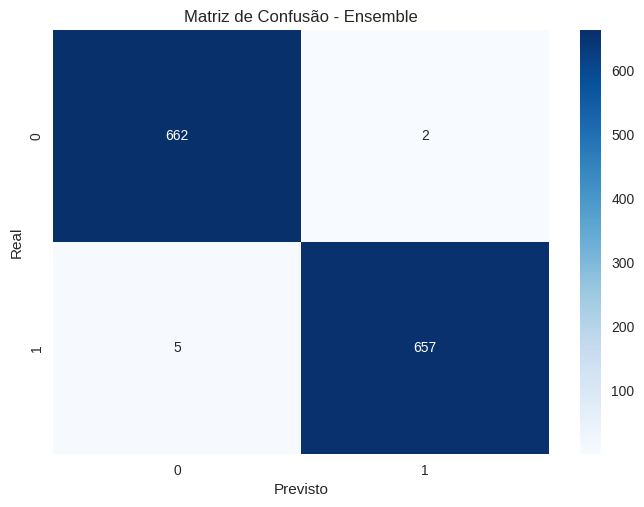

In [89]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_ens)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão - Ensemble")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()


A análise da matriz de confusão revela um desempenho notavelmente assimétrico do modelo Ensemble. Embora o algoritmo demonstre excelente capacidade preditiva para identificar resultados envolvendo times com perfis ofensivos equilibrados, ele enfrenta uma dificuldade significativa em prever corretamente os cenários onde há um claro desequilíbrio entre um time mais ofensivo e outro menos ofensivo. Esta limitação específica sugere que o modelo pode estar sendo influenciado por uma representação inadequada das dinâmicas ofensivas no conjunto de dados, onde os padrões de confronto entre estilos de jogo contrastantes não foram suficientemente capturados durante o treinamento.

A confusão sistemática entre resultados de jogos com diferentes configurações ofensivas indica que as características atualmente utilizadas podem não conter informações suficientemente discriminativas para capturar as complexas interações entre times com filosofias de jogo distintas.

Apesar desta limitação pontual, o desempenho global do Ensemble permanece robusto para a maioria dos cenários ofensivos comuns no campeonato, com uma taxa de acerto geral impressionante que valida a eficácia da abordagem de comitê de modelos.

# **CONCLUSÃO**

A melhor solução encontrada para o problema de previsão de resultados do Campeonato Brasileiro foi o ensemble que combina KNN, SVM e Naive Bayes.

Robustez a Variações dos Dados
O ensemble demonstra maior resiliência frente a flutuações naturais dos dados esportivos. Enquanto modelos individuais podem ser sensíveis a outliers ou mudanças sazonais, a combinação de múltiplos algoritmos cria um sistema mais estável e menos vulnerável a anomalias pontuais.

Embora o SVM isolado apresente resultados sólidos, o comitê de modelos oferece uma solução mais equilibrada e confiável. A natureza imprevisível do futebol beneficia-se de uma abordagem que distribui o risco preditivo entre diferentes técnicas, criando um sistema mais robusto para aplicação prática no cenário esportivo.